# **Census Data KDD**

**Note:** This is a pretty rough first look, but can help decide which is easiest to work w/

**Link:** https://archive.ics.uci.edu/dataset/117/census+income+kdd

Of the datasets seen so far, this one appears to be the most straightforward one, it has appropriate opportunities for handling missing data, and its not overly abundant in terms of features. If we want a super easy and straightforward one, Id prolly lean towards this one. Additionally, the one thing it has over MiniBooNE, is that its features are labeled on the UCI website for the most part, makes presenting more detailed.

However, the only issue that might appear off the bat is the pre-split between a training/test file, worth checking if thats okay. Additionally, the import process is a pain, but already done below so nw there.

This is a classification task, multivariable

---

In [1]:
# Global imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

In [2]:
# NOTE: Uncomment and run this once, or just refer to the info below

# pip install ucimlrepo

In [3]:
# This is the only thing that really needs to change when looking from dataset to dataset, run everything else that follows as normal

UCI_DATASET_ID = 117   # Census-Income (KDD)
NA_VALUES = "?"         # raw file marks missing values this way
TOP_K = 30

In [4]:
# Load the data

dataset = fetch_ucirepo(id=UCI_DATASET_ID)
X = dataset.data.features
y = dataset.data.targets
 
df = pd.concat([X, y], axis=1)
TARGET_COL = y.columns[0]  # fetched dynamically, whatever it's actually named

df = df.replace({NA_VALUES: np.nan, f" {NA_VALUES}": np.nan}) # replace for NaN

print(f"Shape: {df.shape}")
print(f"Target column: '{TARGET_COL}'")
df.head(10)

# Ive got no idea really what not in universe means, but nonetheless :()

Shape: (199523, 42)
Target column: 'income'


,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,ARACE,AREORGN,ASEX,AUNMEM,AUNTYPE,AWKSTAT,CAPGAIN,GAPLOSS,DIVVAL,FILESTAT,GRINREG,GRINST,HHDFMX,HHDREL,MARSUPWRT,MIGMTR1,MIGMTR3,MIGMTR4,MIGSAME,MIGSUN,NOEMP,PARENT,PEFNTVTY,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,AHRSPAY,year,income
0,73,Not in universe,0,0,High school graduate,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
2,18,Not in universe,0,0,10th grade,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,0,95,-50000
3,9,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
4,10,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
5,48,Private,40,10,Some college but no degree,Not in universe,Married-civilian spouse present,Entertainment,Professional specialty,Amer Indian Aleut or Eskimo,All other,Female,No,Not in universe,Full-time schedules,0,0,0,Joint both under 65,Not in universe,Not in universe,Spouse of householder,Spouse of householder,162.61,NaN,NaN,NaN,Not in universe under 1 year old,NaN,1,Not in universe,Philippines,United-States,United-States,Native- Born in the United States,2,Not in universe,2,52,1200,95,-50000
6,42,Private,34,3,Bachelors degree(BA AB BS),Not in universe,Married-civilian spouse present,Finance insurance and real estate,Executive admin and managerial,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,5178,0,0,Joint both under 65,Not in universe,Not in universe,Householder,Householder,1535.86,Nonmover,Nonmover,Nonmover,Yes,Not in universe,6,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
7,28,Private,4,40,High school graduate,Not in universe,Never married,Construction,Handlers equip cleaners etc,White,All other,Female,Not in universe,Job loser - on layoff,Unemployed full-time,0,0,0,Single,Not in universe,Not in universe,Secondary individual,Nonrelative of house

In [5]:
# Basic info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AAGE       199523 non-null  int64  
 1   ACLSWKR    199523 non-null  str    
 2   ADTINK     199523 non-null  int64  
 3   ADTOCC     199523 non-null  int64  
 4   AHGA       199523 non-null  str    
 5   AHSCOL     199523 non-null  str    
 6   AMARITL    199523 non-null  str    
 7   AMJIND     199523 non-null  str    
 8   AMJOCC     199523 non-null  str    
 9   ARACE      199523 non-null  str    
 10  AREORGN    199523 non-null  str    
 11  ASEX       199523 non-null  str    
 12  AUNMEM     199523 non-null  str    
 13  AUNTYPE    199523 non-null  str    
 14  AWKSTAT    199523 non-null  str    
 15  CAPGAIN    199523 non-null  int64  
 16  GAPLOSS    199523 non-null  int64  
 17  DIVVAL     199523 non-null  int64  
 18  FILESTAT   199523 non-null  str    
 19  GRINREG    199523 non-null  str   

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AAGE,199523.0,34.494199,22.310895,0.00,15.000,33.00,50.00,90.0
ADTINK,199523.0,15.352320,18.067129,0.00,0.000,0.00,33.00,51.0
ADTOCC,199523.0,11.306556,14.454204,0.00,0.000,0.00,26.00,46.0
CAPGAIN,199523.0,434.718990,4697.531280,0.00,0.000,0.00,0.00,99999.0
GAPLOSS,199523.0,37.313788,271.896428,0.00,0.000,0.00,0.00,4608.0
DIVVAL,199523.0,197.529533,1984.163658,0.00,0.000,0.00,0.00,99999.0
MARSUPWRT,199523.0,1740.380269,993.768156,37.87,1061.615,1618.31,2188.61,18656.3
NOEMP,199523.0,1.956180,2.365126,0.00,0.000,1.00,4.00,6.0
SEOTR,199523.0,0.175438,0.553694,0.00,0.000,0.00,0.00,2.0
VETYN,199523.0,1.514833,0.851473,0.00,2.000,2.00,2.00,2.0


In [7]:
if TARGET_COL in df.columns:
    print(df[TARGET_COL].value_counts())
    print()
    print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
else:
    print(f"Column '{TARGET_COL}' not found — update TARGET_COL in the config cell.")

income
-50000      187141
 50000+.     12382
Name: count, dtype: int64

income
-50000      93.79 %
 50000+.     6.21 %
Name: proportion, dtype: str


In [8]:
# Null value check

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
 
null_summary = (
    pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
 
print(f"Columns with at least one missing value: {len(null_summary)} / {df.shape[1]}")
null_summary.head(30)

Columns with at least one missing value: 8 / 42


,n_missing,pct_missing
MIGMTR1,99696,49.97
MIGMTR3,99696,49.97
MIGMTR4,99696,49.97
MIGSUN,99696,49.97
PEFNTVTY,6713,3.36
PEMNTVTY,6119,3.07
PENATVTY,3393,1.70
GRINST,708,0.35


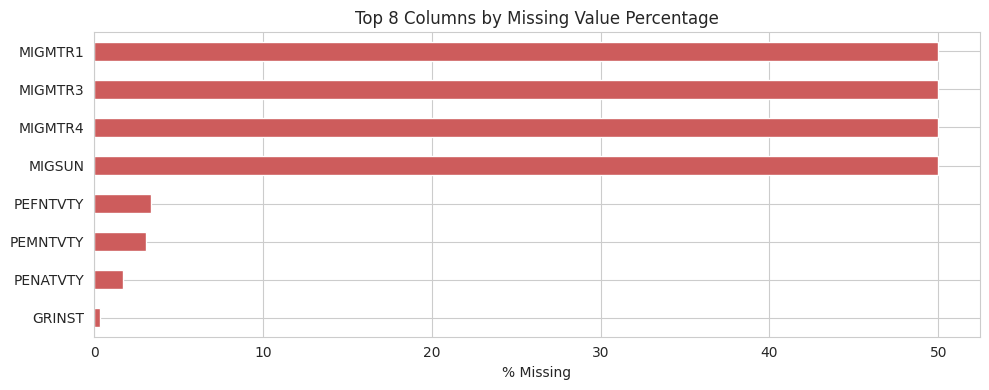

In [9]:
top_n_missing = min(25, len(null_summary))
 
if top_n_missing > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, top_n_missing * 0.3)))
    null_summary.head(top_n_missing)["pct_missing"].sort_values().plot(
        kind="barh", ax=ax, color="indianred"
    )
    ax.set_xlabel("% Missing")
    ax.set_title(f"Top {top_n_missing} Columns by Missing Value Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

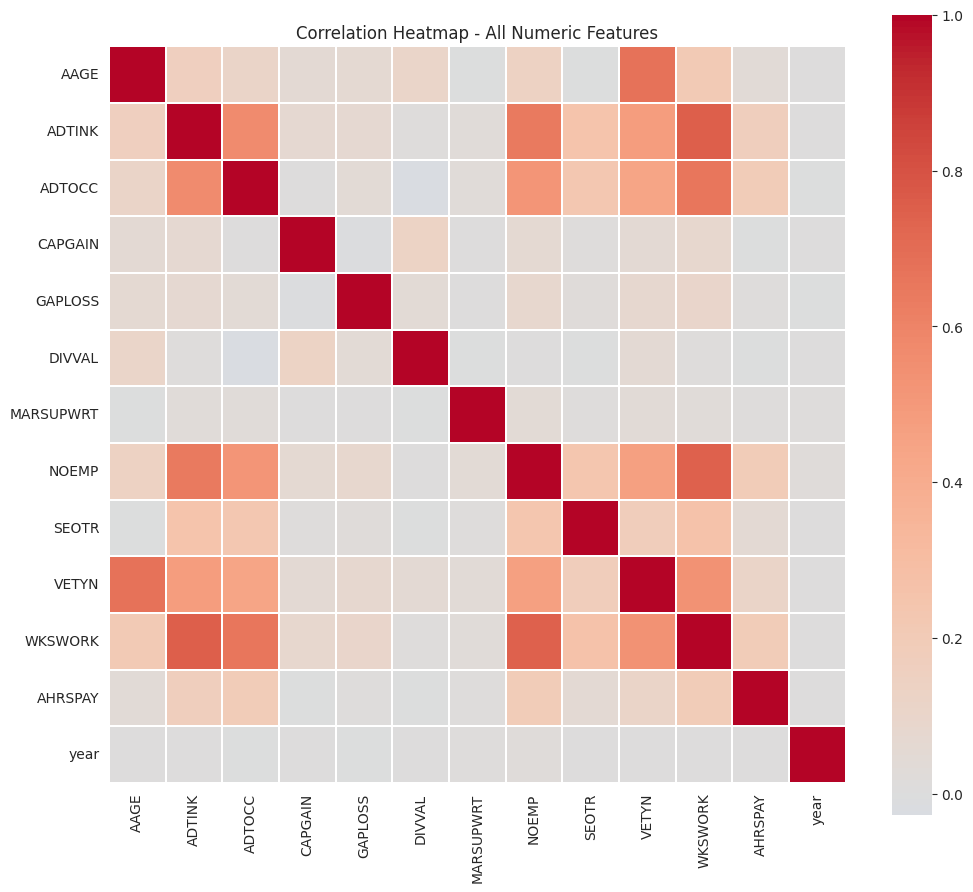

In [10]:
# Correlation heatmap

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
 
if TOP_K is not None and TOP_K < len(numeric_df.columns):
    avg_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
    plot_cols = avg_abs_corr.head(TOP_K).index
    heatmap_title = f"Correlation Heatmap - Top {TOP_K} Most Correlated Features"
else:
    plot_cols = numeric_df.columns
    heatmap_title = "Correlation Heatmap - All Numeric Features"
 
fig, ax = plt.subplots(figsize=(min(24, len(plot_cols) * 0.5 + 4), min(20, len(plot_cols) * 0.5 + 4)))
sns.heatmap(
    corr_matrix.loc[plot_cols, plot_cols],
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title(heatmap_title)
plt.tight_layout()
plt.show()

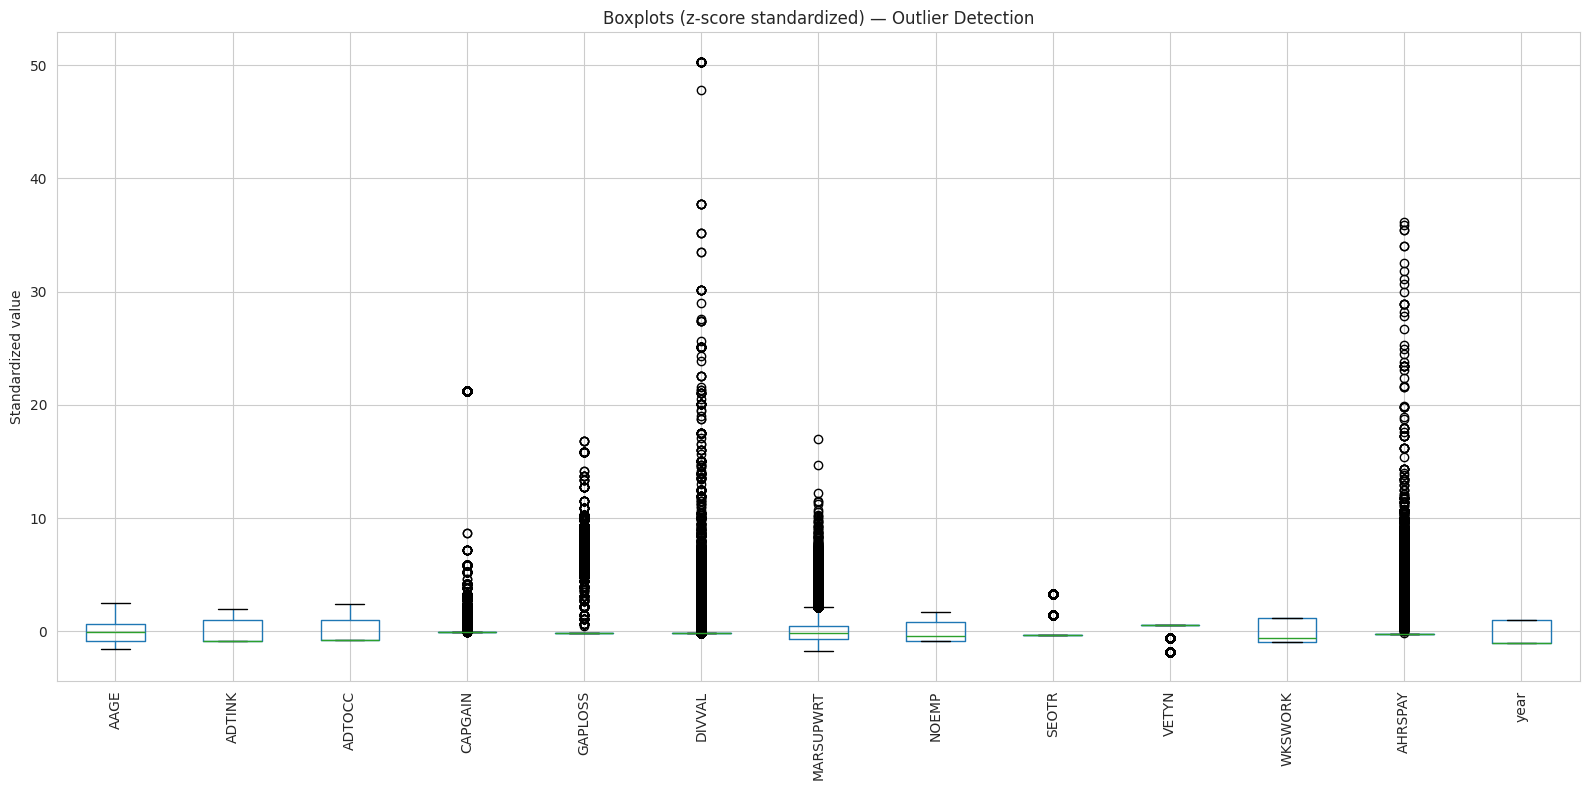

In [11]:
boxplot_cols = plot_cols[:20]  # cap at 20 for readability regardless of TOP_K
standardized = numeric_df[boxplot_cols].apply(zscore, nan_policy="omit")
 
fig, ax = plt.subplots(figsize=(16, 8))
standardized.boxplot(ax=ax, rot=90)
ax.set_title("Boxplots (z-score standardized) — Outlier Detection")
ax.set_ylabel("Standardized value")
plt.tight_layout()
plt.show()

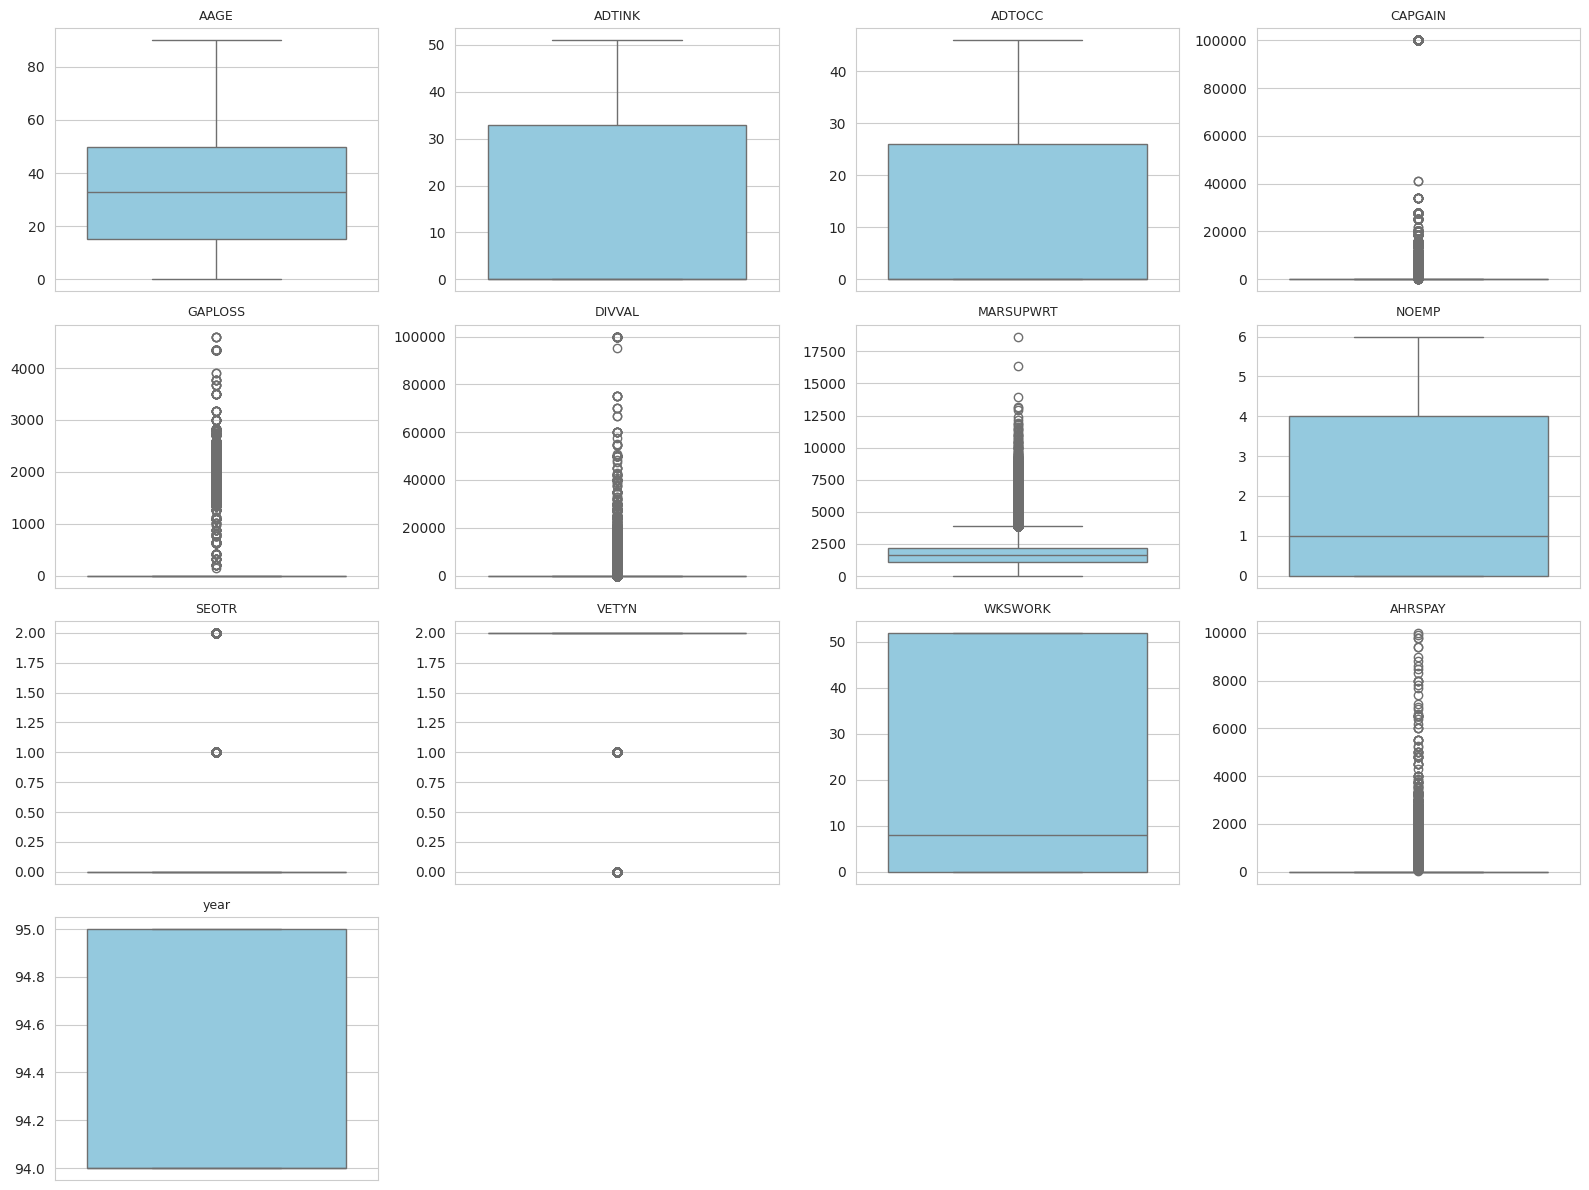

In [12]:
n_cols = 4
n_rows = int(np.ceil(len(boxplot_cols) / n_cols))
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
 
for i, col in enumerate(boxplot_cols):
    sns.boxplot(y=numeric_df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
 
for j in range(len(boxplot_cols), len(axes)):
    axes[j].axis("off")
 
plt.tight_layout()
plt.show()

In [13]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())
 
outlier_counts = (
    numeric_df[boxplot_cols]
    .apply(iqr_outlier_count)
    .sort_values(ascending=False)
    .to_frame("n_outliers")
)
outlier_counts["pct_outliers"] = (outlier_counts["n_outliers"] / len(numeric_df) * 100).round(2)
outlier_counts

,n_outliers,pct_outliers
VETYN,49393,24.76
DIVVAL,21141,10.60
SEOTR,18851,9.45
AHRSPAY,11304,5.67
CAPGAIN,7379,3.70
MARSUPWRT,6238,3.13
GAPLOSS,3906,1.96
AAGE,0,0.00
ADTOCC,0,0.00
ADTINK,0,0.00
